In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [5]:
# Load layers
buildings = gpd.read_file("../../layers/bcn_catastral_building.gpkg")
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")

# Ensure CRS is the same
buildings = buildings.to_crs(noise_streets.crs)
display(buildings.head(30))

,gml_id,lowerCorner,upperCorner,beginLifespanVersion,conditionOfConstruction,beginning,end,endLifespanVersion,informationSystem,reference,...,numberOfBuildingUnits,numberOfDwellings,numberOfFloorsAboveGround,documentLink,format,sourceStatus,officialAreaReference,value,value_uom,geometry
0,ES.SDGC.BU.0004701DF3800C,429945.651 4580072.933,429973.141 4580093.773,2001-10-29,functional,1970-01-01T00:00:00,1970-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0004701DF3800C,...,1,1,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,346,m2,"POLYGON ((429972.94 4580072.933, 429946.7 4580..."
1,ES.SDGC.BU.0004702DF3800C,429884.2815 4580170.874,429920.1415 4580191.7435,2001-10-29,functional,1970-01-01T00:00:00,1970-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0004702DF3800C,...,2,0,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,7366,m2,"MULTIPOLYGON (((429891.252 4580183.734, 429903..."
2,ES.SDGC.BU.0005401DF3800E,429944.683 4580384.3335,429957.873 4580404.9135,2001-10-29,functional,1975-01-01T00:00:00,1975-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005401DF3800E,...,10,7,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,776,m2,"POLYGON ((429957.363 4580401.054, 429956.083 4..."
3,ES.SDGC.BU.0005403DF3800E,429969.453 4580395.3435,429986.2135 4580409.0335,2001-10-29,functional,1904-01-01T00:00:00,1904-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005403DF3800E,...,12,10,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,709,m2,"POLYGON ((429981.014 4580406.584, 429982.574 4..."
4,ES.SDGC.BU.0005404DF3800E,429972.3035 4580406.1435,429988.9735 4580418.6935,2001-10-29,functional,1936-01-01T00:00:00,1936-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005404DF3800E,...,20,17,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,926,m2,"POLYGON ((429987.824 4580410.624, 429987.164 4..."
5,ES.SDGC.BU.0005405DF3800E,429986.2135 4580401.4035,430002.0335 4580414.5835,2024-07-08,functional,1936-01-01T00:00:00,1936-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005405DF3800E,...,12,11,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,823,m2,"POLYGON ((429988.02 4580411.314, 429988.094 45..."
6,ES.SDGC.BU.0005406DF3800E,429983.853 4580391.7435,429999.4035 4580405.1135,2001-10-29,functional,1936-01-01T00:00:00,1936-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005406DF3800E,...,11,10,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,575,m2,"POLYGON ((429985.223 4580401.034, 429986.214 4..."
7,ES.SDGC.BU.0005407DF3800E,429969.593 4580379.6135,429996.663 4580398.4135,2001-10-29,functional,1900-01-01T00:00:00,1900-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005407DF3800E,...,1,1,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,450,m2,"POLYGON ((429974.063 4580388.684, 429974.703 4..."
8,ES.SDGC.BU.0005408DF3800E,429967.883 4580373.1835,429993.233 4580386.1735,2001-10-29,functional,1936-01-01T00:00:00,1936-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005408DF3800E,...,3,2,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,346,m2,"POLYGON ((429977.523 4580381.874, 429978.023 4..."
9,ES.SDGC.BU.0005409DF3800E,429966.243 4580367.2235,429991.413 4580379.9235,2001-10-29,functional,1920-01-01T00:00:00,1920-01-01T00:00:00,NaT,https://www1.sedecatastro.gob.es/CYCBienInmueb...,0005409DF3800E,...,6,6,None,http://ovc.catastro.meh.es/OVCServWeb/OVCWcfLi...,jpeg,NotOfficial,grossFloorArea,521,m2,"POLYGON ((429975.053 4580377.914, 429976.433 4..."


All buildings have assigned floors. Median is: 3.0


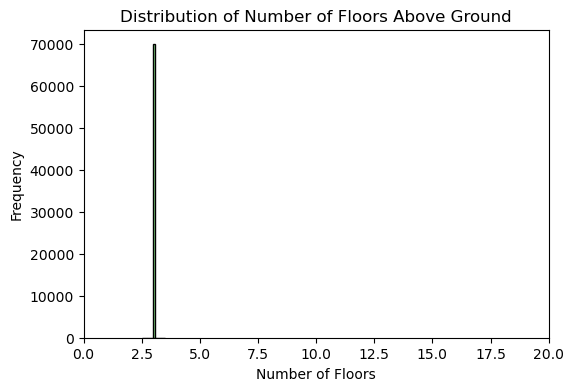

In [3]:
# Process the number of floors
def clean_floors_col(series):
    # Remove non-numeric characters and convert to float
    return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Initialize a series for estimated floors
floors = clean_floors_col(buildings['numberOfFloorsAboveGround'])

# Impute missing values with the median number of floors
median_floors = floors.median()
if np.isnan(median_floors):
    median_floors = 3.0  # Fallback to 3 stories if dataset is too sparse
    
floors = floors.fillna(median_floors)
buildings['estimated_floors'] = floors

print(f"All buildings have assigned floors. Median is: {median_floors:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
buildings['estimated_floors'].plot(kind='hist', bins=20, ax=ax, color='lightgreen', edgecolor='black')
ax.set_title('Distribution of Number of Floors Above Ground')
ax.set_xlabel('Number of Floors')
ax.set_xlim(0, 20)  # Focus on the majority
plt.show()

In [4]:
def calculate_building_floors_in_buffer(streets_gdf, buildings_gdf, buffer_size):
    print(f"Evaluating {buffer_size}m buffers...")
    # Buffer the streets
    buffered_streets = streets_gdf.copy()
    buffered_streets['geometry'] = buffered_streets.geometry.buffer(buffer_size)
    
    # Keep only target columns for spatial join to reduce memory usage
    bldgs = buildings_gdf[['estimated_floors', 'geometry']].copy()
    
    # Spatial join: Which buildings intersect which street buffer?
    joined = gpd.sjoin(buffered_streets[['TRAM', 'geometry']], bldgs, how='left', predicate='intersects')
    
    # If a street buffer hits nothing, it will have NaN in estimated_floors. Treatment: 0.
    joined['estimated_floors'] = joined['estimated_floors'].fillna(0)
    
    # Group by street and calculate aggregate stats
    agg_funcs = {
        'estimated_floors': ['mean', 'max']
    }
    grouped = joined.groupby('TRAM').agg(agg_funcs)
    
    # Flatten MultiIndex columns
    grouped.columns = [f"catastral_bldg_floors_{col[1]}_{buffer_size}m" for col in grouped.columns]
    
    return grouped.reset_index()

features_50m = calculate_building_floors_in_buffer(noise_streets, buildings, 50)
features_100m = calculate_building_floors_in_buffer(noise_streets, buildings, 100)

display(features_50m.head())

Evaluating 50m buffers...
Evaluating 100m buffers...


,TRAM,catastral_bldg_floors_mean_50m,catastral_bldg_floors_max_50m
0,LRD0001,3.0,3.0
1,LRD0002,3.0,3.0
2,LRD0003,3.0,3.0
3,LRD0004,3.0,3.0
4,LRD0005,0.0,0.0


In [5]:
dataset = pd.DataFrame({'street_id': noise_streets['TRAM']})

dataset = dataset.merge(features_50m, left_on='street_id', right_on='TRAM', how='left').drop(columns=['TRAM'])
dataset = dataset.merge(features_100m, left_on='street_id', right_on='TRAM', how='left').drop(columns=['TRAM'])

dataset = dataset.fillna(0)
display(dataset.head())

output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "catastral_building_floors.csv"), index=False)
print("Exported catastral_building_floors.csv")

,street_id,catastral_bldg_floors_mean_50m,catastral_bldg_floors_max_50m,catastral_bldg_floors_mean_100m,catastral_bldg_floors_max_100m
0,T04719W,3.0,3.0,3.0,3.0
1,T19941Z,3.0,3.0,3.0,3.0
2,T18111R,3.0,3.0,3.0,3.0
3,T03222Y,3.0,3.0,3.0,3.0
4,T17625I,3.0,3.0,3.0,3.0


Exported catastral_building_floors.csv


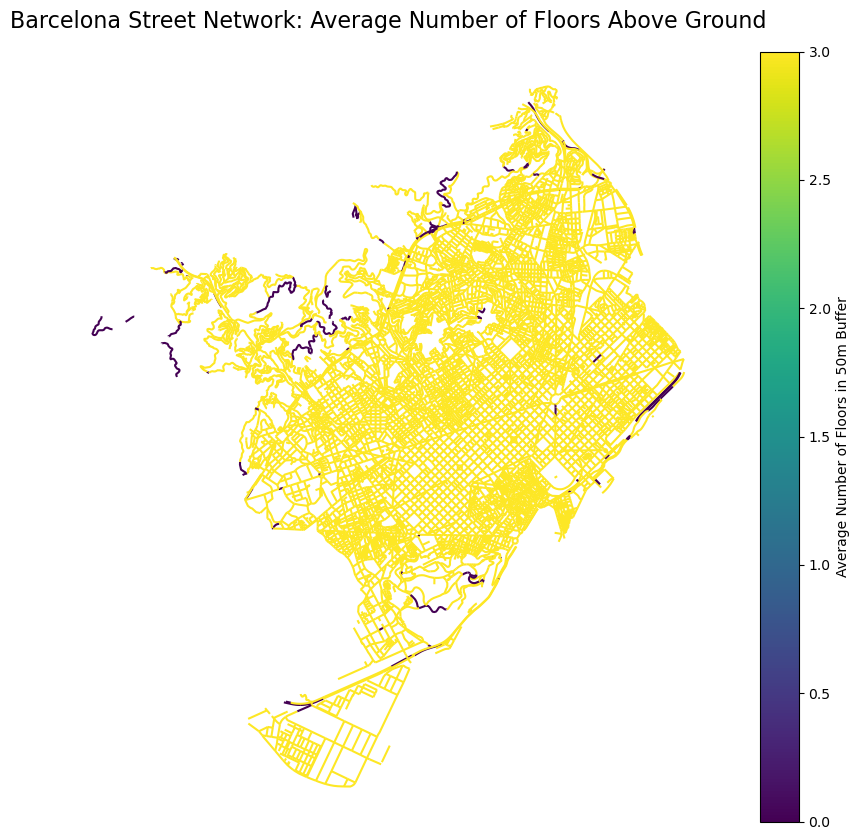

In [6]:
# Temporarily merge the result back to the street geometries for plotting
viz_gdf = noise_streets.merge(dataset[['street_id', 'catastral_bldg_floors_mean_50m']], left_on='TRAM', right_on='street_id')

fig, ax = plt.subplots(figsize=(12, 10))

# Cap at 95th percentile so super tall buildings don't wash out the color map gradient
vmax_floors = viz_gdf['catastral_bldg_floors_mean_50m'].quantile(0.95)

viz_gdf.plot(
    column='catastral_bldg_floors_mean_50m',
    ax=ax,
    cmap='viridis',
    linewidth=1.5,
    legend=True,
    legend_kwds={'label': "Average Number of Floors in 50m Buffer"},
    vmax=vmax_floors
)

ax.set_title("Barcelona Street Network: Average Number of Floors Above Ground", fontsize=16)
ax.set_axis_off()
plt.show()